In [1]:
from simulator import Config, Simulator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

## 1. Simulator Configuration

In [2]:
# Common configuration for all simulations
config = Config()
config.NODE_POWER_W = 0.2  # node consumption (W)

simulator = Simulator(config)
print(f"Node power: {config.NODE_POWER_W * 1000} mW")
print(f"Number of panel areas to evaluate: {len(config.PANEL_AREAS_M2)}")
print(f"Number of batteries to evaluate: {len(config.BATTERY_SPECS)}")
print(f"PMU efficiency values: {config.PMU_ETA_VALUES}")

Node power: 200.0 mW
Number of panel areas to evaluate: 14
Number of batteries to evaluate: 12
PMU efficiency values: [0.87, 0.9, 0.95, 0.98]


## 2. Run Simulations for Quito and Ciudad Real

In [ ]:
import tmy

# Define locations and their data files
locations = {
    'Ciudad Real': tmy.get_tmy_csv('Ciudad Real', 2005, 2023),
    'Quito':       tmy.get_tmy_csv('Quito', 2005, 2023),
}

# Dictionary to store all results
all_results = {}

INFO:tmy:Coordinates for Ciudad Real: lat=38.9597348, lon=-3.8828744
INFO:tmy:{
  "location": {
    "latitude": 38.9597348,
    "longitude": -3.8828744,
    "elevation": 633.0,
    "irradiance_time_offset": 0.1686
  },
  "meteo_data": {
    "radiation_db": "PVGIS-SARAH3",
    "meteo_db": "ERA5",
    "year_min": 2007,
    "year_max": 2020,
    "use_horizon": true,
    "horizon_db": "DEM-calculated"
  }
}
INFO:tmy:CSV already exists, skipping download: raw-data/Quito_2007_2020.csv


In [4]:
# Run simulation for each location
print("Running simulations...\n")

for location, filepath in locations.items():
    print(f"Simulating: {location}...")
    results = simulator.run_full_simulation(filepath)
    all_results[location] = results

    # Show basic statistics
    summary = results['summary']
    summary["viable"] = summary["failure_hours"] == 0
    viable_configs = summary[summary['viable'] == True]
    print(f"  - Viable configurations: {len(viable_configs)} / {len(summary)}")
    print(f"  - Max score: {summary['score'].max():.4f}")
    print()

Running simulations...

Simulating: Ciudad Real...
Loading irradiance data...
Computing PV power...
Computing hourly balance...
Simulating battery SoC...
Evaluating viability...
Computing optimal scores...
Done!
  - Viable configurations: 48 / 672
  - Max score: 0.3128

Simulating: Quito...
Loading irradiance data...
Computing PV power...
Computing hourly balance...
Simulating battery SoC...
Evaluating viability...
Computing optimal scores...
Done!
  - Viable configurations: 100 / 672
  - Max score: 0.5637



## 3. Extract and Compare the Best Solutions

In [5]:
# Create DataFrame with the best configurations for each location
best_solutions = []

for location, results in all_results.items():
    summary = results['summary'].copy().sort_values('score', ascending=False)

    # Filter only viable configurations
    viable = summary[summary['viable'] == True].copy()
    summary = summary.head(10)
    summary['location'] = location
    best_solutions.append(summary)

    # if len(viable) > 0:
    #     # Get the best configuration (highest score)
    #     best = viable.loc[viable['score'].idxmax()].copy()
    #     best['location'] = location
    #     best_solutions.append(best)

df_best = pd.concat(best_solutions, ignore_index=True)

# Add min/avg SoC for each best configuration (computed from df_soc)
if not df_best.empty:
    min_socs = []
    avg_socs = []
    for _, row in df_best.iterrows():
        df_soc = all_results[row['location']]['df_soc']
        mask = (
            (df_soc['panel_area_m2'] == row['panel_area_m2']) &
            (df_soc['C_batt_Ah'] == row['C_batt_Ah']) &
            (df_soc['eta_PMU'] == row['eta_PMU'])
        )
        soc_subset = df_soc.loc[mask, 'SoC']
        min_socs.append(soc_subset.min())
        avg_socs.append(soc_subset.mean())

    df_best['min_SoC'] = min_socs
    df_best['avg_SoC'] = avg_socs

df_best[['location', 'panel_area_m2', 'C_batt_Ah', 'eta_PMU', 'score', 'soc_full_fraction', 'net_Ah']]

,location,panel_area_m2,C_batt_Ah,eta_PMU,score,soc_full_fraction,net_Ah
0,Ciudad Real,0.025,2.0,0.95,0.312763,0.329110,-1335.565280
1,Ciudad Real,0.025,2.0,0.98,0.305116,0.339041,-1453.061849
2,Ciudad Real,0.016,3.2,0.98,0.299974,0.271804,-759.100269
3,Ciudad Real,0.025,2.3,0.95,0.278743,0.329110,-1335.565280
4,Ciudad Real,0.031,1.6,0.98,0.278712,0.363699,-1915.643857
5,Ciudad Real,0.025,2.3,0.98,0.271096,0.339041,-1453.061849
6,Ciudad Real,0.025,2.5,0.90,0.269423,0.311758,-1146.492171
7,Ciudad Real,0.025,2.5,0.95,0.256063,0.329110,-1335.565280
8,Ciudad Real,0.031,2.0,0.90,0.250756,0.341096,-1536.940418
9,Ciudad Real,0.025,2.5,0.98,0.248416,0.339041,-1453.061849


## 4. Comparative Visualizations

### 4.1 Panel Area Comparison

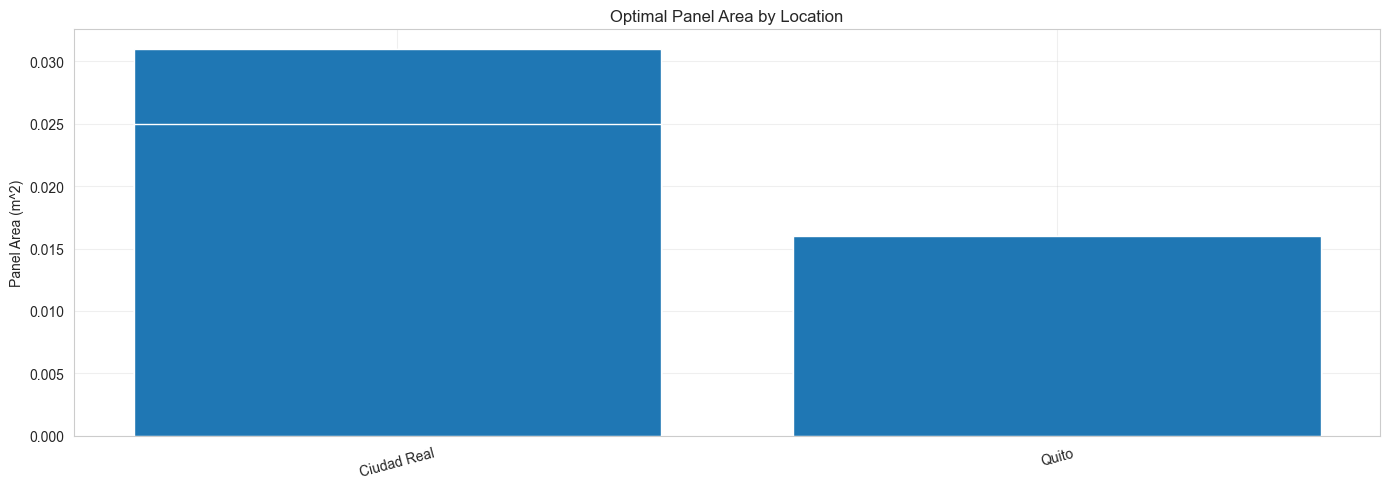

In [6]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Panel area in m^2
ax1.bar(df_best['location'], df_best['panel_area_m2'])
ax1.set_ylabel('Panel Area (m^2)')
ax1.set_title('Optimal Panel Area by Location')
ax1.tick_params(axis='x', rotation=15)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Battery Capacity Comparison

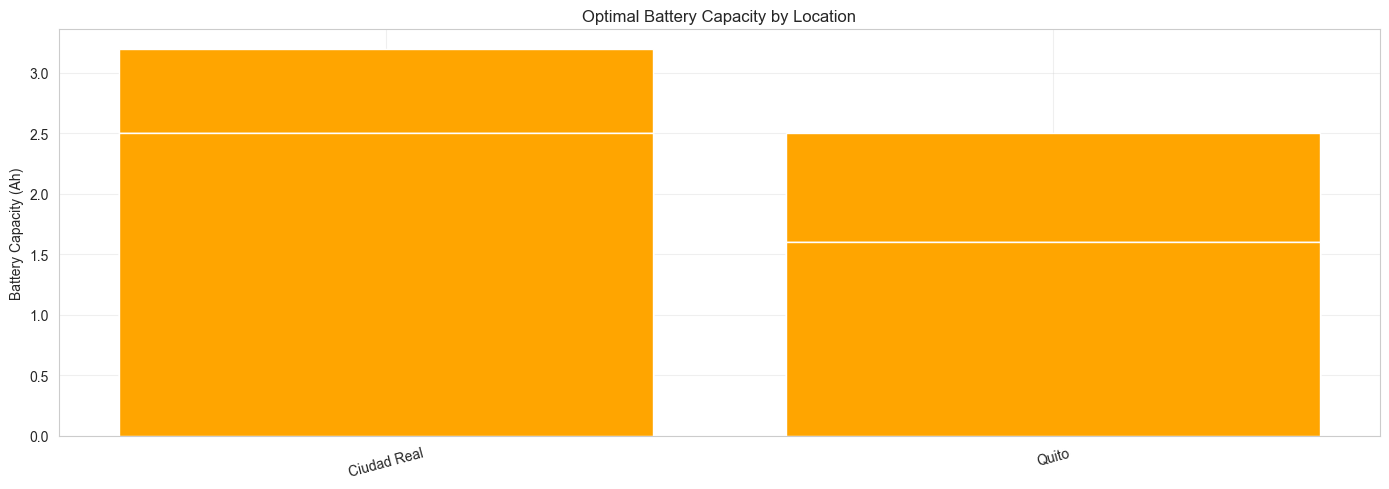

In [7]:
fig, ax1 = plt.subplots(1, 1, figsize=(14, 5))

ax1.bar(df_best['location'], df_best['C_batt_Ah'], color='orange')
ax1.set_ylabel('Battery Capacity (Ah)')
ax1.set_title('Optimal Battery Capacity by Location')
ax1.tick_params(axis='x', rotation=15)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.3 Comparison of PMU Efficiencies and Scores

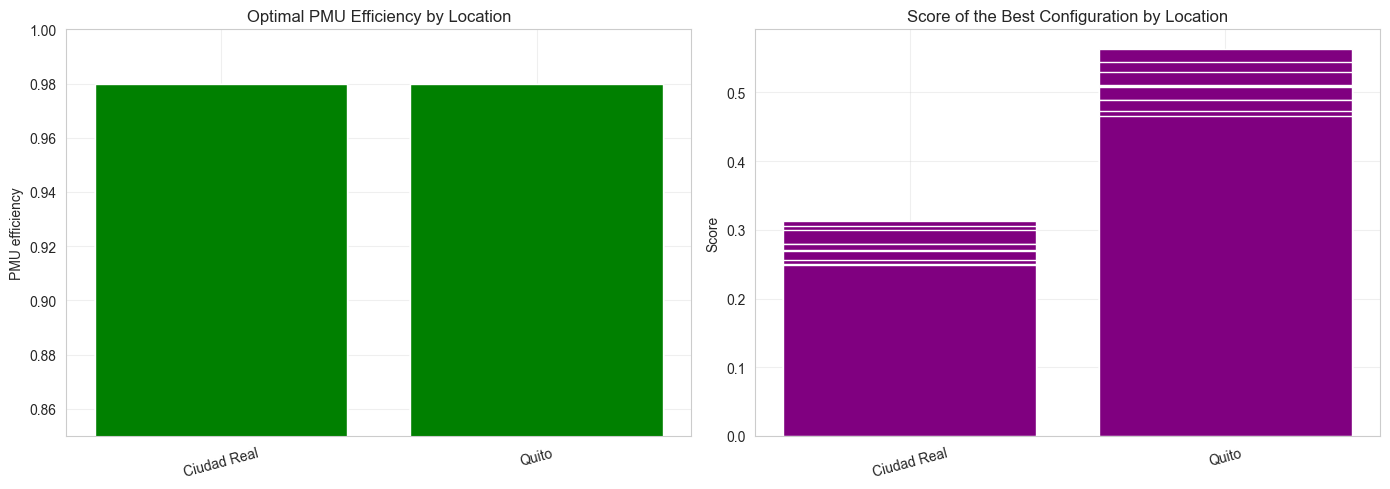

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PMU efficiency
ax1.bar(df_best['location'], df_best['eta_PMU'], color='green')
ax1.set_ylabel('PMU efficiency')
ax1.set_ylim([0.85, 1.0])
ax1.set_title('Optimal PMU Efficiency by Location')
ax1.tick_params(axis='x', rotation=15)
ax1.grid(True, alpha=0.3)

# Score
ax2.bar(df_best['location'], df_best['score'], color='purple')
ax2.set_ylabel('Score')
ax2.set_title('Score of the Best Configuration by Location')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4 SoC Comparison

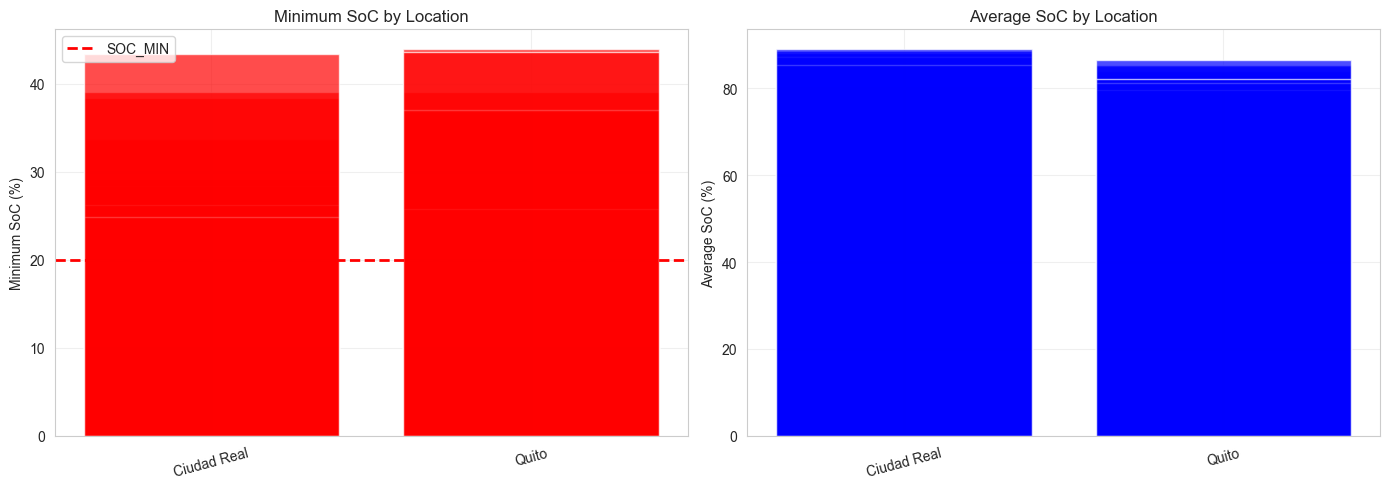

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Minimum SoC
ax1.bar(df_best['location'], df_best['min_SoC'] * 100, color='red', alpha=0.7)
ax1.axhline(y=config.SOC_MIN * 100, color='r', linestyle='--', linewidth=2, label='SOC_MIN')
ax1.set_ylabel('Minimum SoC (%)')
ax1.set_title('Minimum SoC by Location')
ax1.tick_params(axis='x', rotation=15)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Average SoC
ax2.bar(df_best['location'], df_best['avg_SoC'] * 100, color='blue', alpha=0.7)
ax2.set_ylabel('Average SoC (%)')
ax2.set_title('Average SoC by Location')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5 Multi-variable Summary Chart

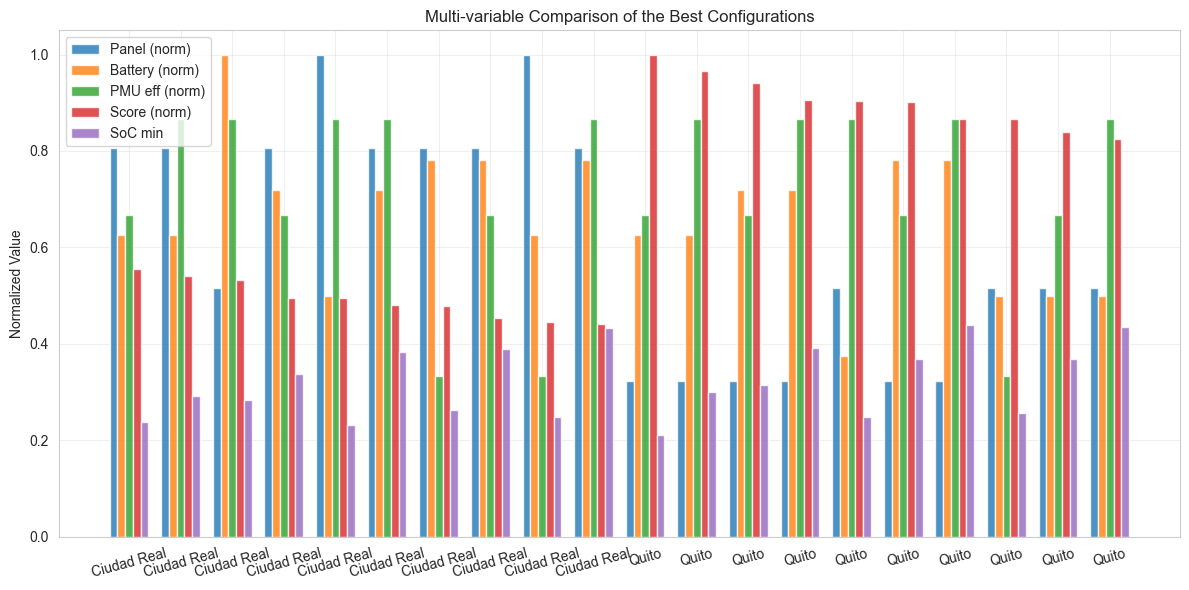

In [10]:
# Normalize values to compare in a single plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_best))
width = 0.15

# Normalize values
panel_norm = df_best['panel_area_m2'] / df_best['panel_area_m2'].max()
battery_norm = df_best['C_batt_Ah'] / df_best['C_batt_Ah'].max()
pmu_norm = (df_best['eta_PMU'] - 0.85) / (1.0 - 0.85)  # Normalize between 0.85 and 1.0
score_norm = df_best['score'] / df_best['score'].max()
soc_min_norm = df_best['min_SoC']

ax.bar(x - 2*width, panel_norm, width, label='Panel (norm)', alpha=0.8)
ax.bar(x - width, battery_norm, width, label='Battery (norm)', alpha=0.8)
ax.bar(x, pmu_norm, width, label='PMU eff (norm)', alpha=0.8)
ax.bar(x + width, score_norm, width, label='Score (norm)', alpha=0.8)
ax.bar(x + 2*width, soc_min_norm, width, label='SoC min', alpha=0.8)

ax.set_ylabel('Normalized Value')
ax.set_title('Multi-variable Comparison of the Best Configurations')
ax.set_xticks(x)
ax.set_xticklabels(df_best['location'], rotation=15)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Viable Configuration Distribution Analysis


Distribution of Viable Configurations:
      Location  Viable  Total  Not Viable  % Viable
0  Ciudad Real      48    672         624      7.14
1        Quito     100    672         572     14.88


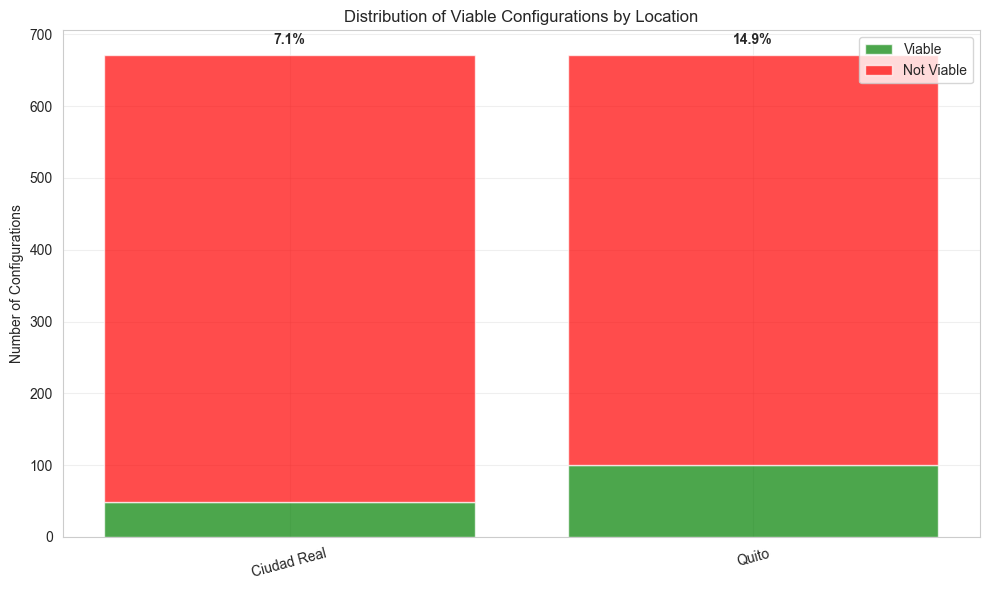

In [11]:
# Compare number of viable configurations per location
viable_counts = {}
total_configs = {}

for location, results in all_results.items():
    summary = results['summary']
    viable_counts[location] = (summary['viable'] == True).sum()
    total_configs[location] = len(summary)

# Create DataFrame for visualization
df_viable = pd.DataFrame({
    'Location': list(viable_counts.keys()),
    'Viable': list(viable_counts.values()),
    'Total': list(total_configs.values())
})

df_viable['Not Viable'] = df_viable['Total'] - df_viable['Viable']
df_viable['% Viable'] = (df_viable['Viable'] / df_viable['Total'] * 100).round(2)

print("\nDistribution of Viable Configurations:")
print(df_viable)

# Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(df_viable))
ax.bar(x_pos, df_viable['Viable'], label='Viable', color='green', alpha=0.7)
ax.bar(x_pos, df_viable['Not Viable'], bottom=df_viable['Viable'],
       label='Not Viable', color='red', alpha=0.7)

ax.set_ylabel('Number of Configurations')
ax.set_title('Distribution of Viable Configurations by Location')
ax.set_xticks(x_pos)
ax.set_xticklabels(df_viable['Location'], rotation=15)
ax.legend()
ax.grid(True, alpha=0.3)

# Add percentages on bars
for i, (idx, row) in enumerate(df_viable.iterrows()):
    ax.text(i, row['Total'] + 10, f"{row['% Viable']:.1f}%",
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Climate Data Comparison

In [12]:
# Load irradiance data for comparative analysis
climate_data = {}

for location, filepath in locations.items():
    df_climate = pd.read_csv(filepath)
    climate_data[location] = df_climate

# Compare irradiance statistics
print("Irradiance Statistics by Location:")
print("=" * 80)

climate_stats = []
for location, df in climate_data.items():
    stats = {
        'Location': location,
        'G(h) Mean': df['G(h)'].mean(),
        'G(h) Max': df['G(h)'].max(),
        'G(h) Min': df['G(h)'].min(),
        'T Mean': df['Temperature'].mean(),
        'T Max': df['Temperature'].max(),
        'T Min': df['Temperature'].min()
    }
    climate_stats.append(stats)

df_climate_stats = pd.DataFrame(climate_stats)
df_climate_stats

Irradiance Statistics by Location:


,Location,G(h) Mean,G(h) Max,G(h) Min,T Mean,T Max,T Min
0,Ciudad Real,208.977968,1066.00,0.0,15.398934,38.57,-3.47
1,Quito,183.900285,1007.55,0.0,12.764475,21.81,5.90


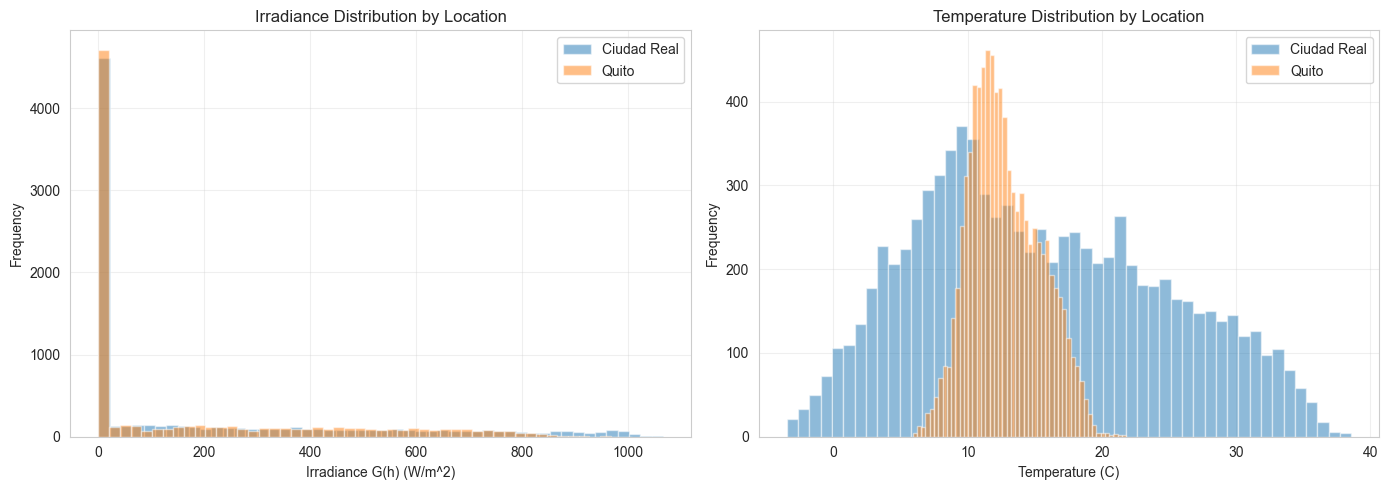

In [13]:
# Visualize irradiance distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Irradiance
for location, df in climate_data.items():
    ax1.hist(df['G(h)'], bins=50, alpha=0.5, label=location)
ax1.set_xlabel('Irradiance G(h) (W/m^2)')
ax1.set_ylabel('Frequency')
ax1.set_title('Irradiance Distribution by Location')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Temperature
for location, df in climate_data.items():
    ax2.hist(df['Temperature'], bins=50, alpha=0.5, label=location)
ax2.set_xlabel('Temperature (C)')
ax2.set_ylabel('Frequency')
ax2.set_title('Temperature Distribution by Location')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.1 Annual Irradiance Comparison

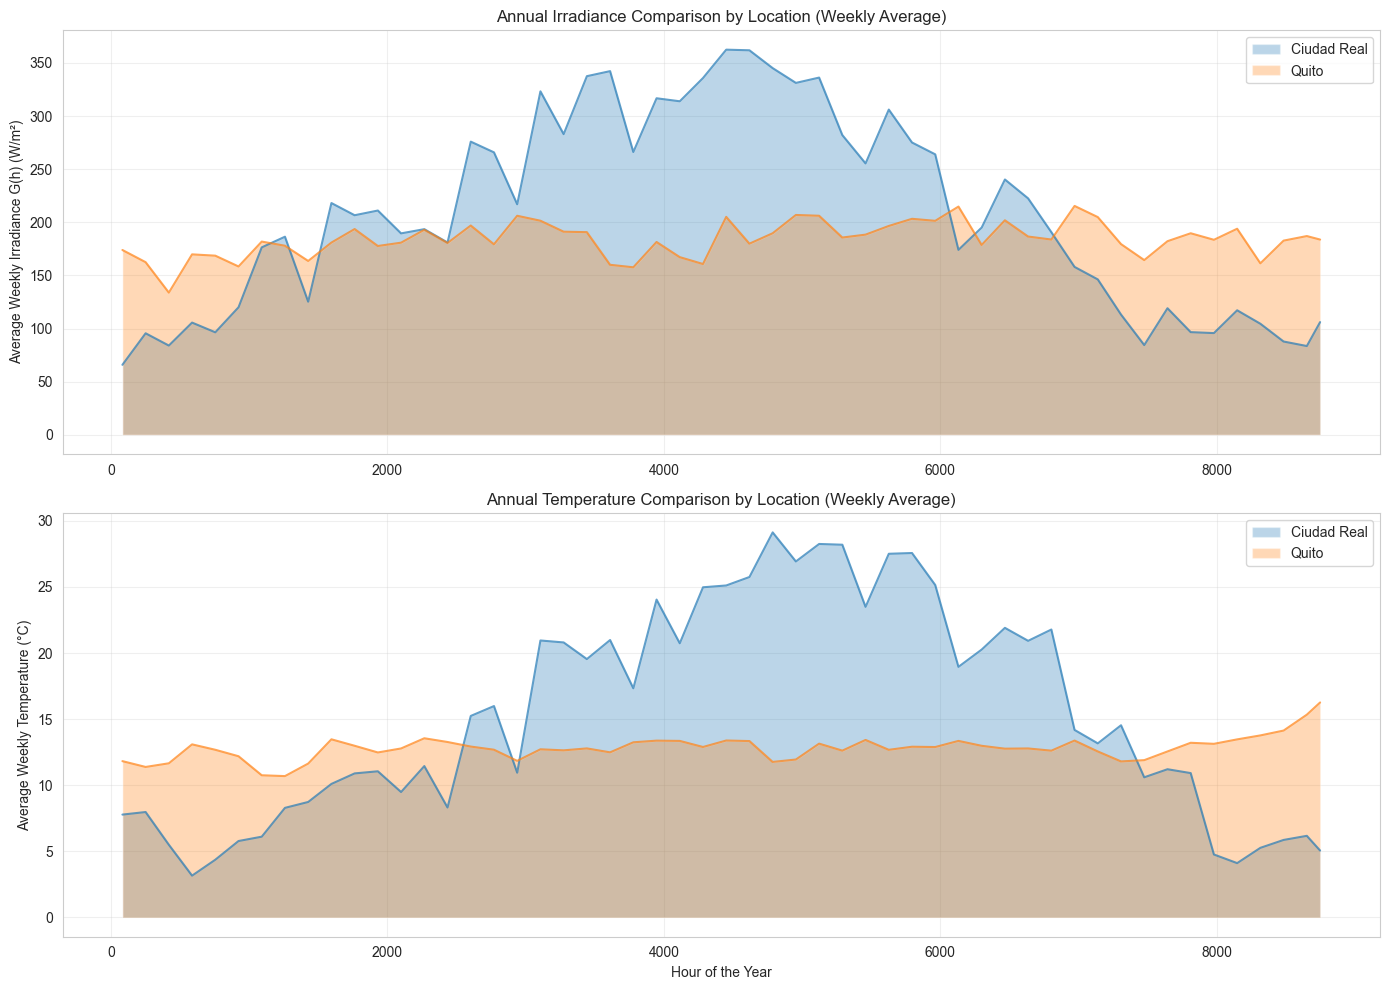

In [14]:
# Plot irradiance and temperature throughout the year for all locations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

for location, df in climate_data.items():
    # Group by week and calculate mean values
    df_copy = df.copy()
    df_copy['hour_index'] = range(len(df_copy))
    df_copy['week'] = df_copy['hour_index'] // 168  # 168 hours per week

    weekly_data = df_copy.groupby('week').agg({
        'G(h)': 'mean',
        'Temperature': 'mean',
        'hour_index': 'mean'
    }).reset_index()

    # Irradiance plot
    ax1.fill_between(weekly_data['hour_index'], weekly_data['G(h)'], alpha=0.3, label=location)
    ax1.plot(weekly_data['hour_index'], weekly_data['G(h)'], alpha=0.7, linewidth=1.5)

    # Temperature plot
    ax2.fill_between(weekly_data['hour_index'], weekly_data['Temperature'], alpha=0.3, label=location)
    ax2.plot(weekly_data['hour_index'], weekly_data['Temperature'], alpha=0.7, linewidth=1.5)

# Configure irradiance plot
ax1.set_ylabel('Average Weekly Irradiance G(h) (W/m²)')
ax1.set_title('Annual Irradiance Comparison by Location (Weekly Average)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Configure temperature plot
ax2.set_xlabel('Hour of the Year')
ax2.set_ylabel('Average Weekly Temperature (°C)')
ax2.set_title('Annual Temperature Comparison by Location (Weekly Average)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. SoC Time Evolution in the Best Configurations

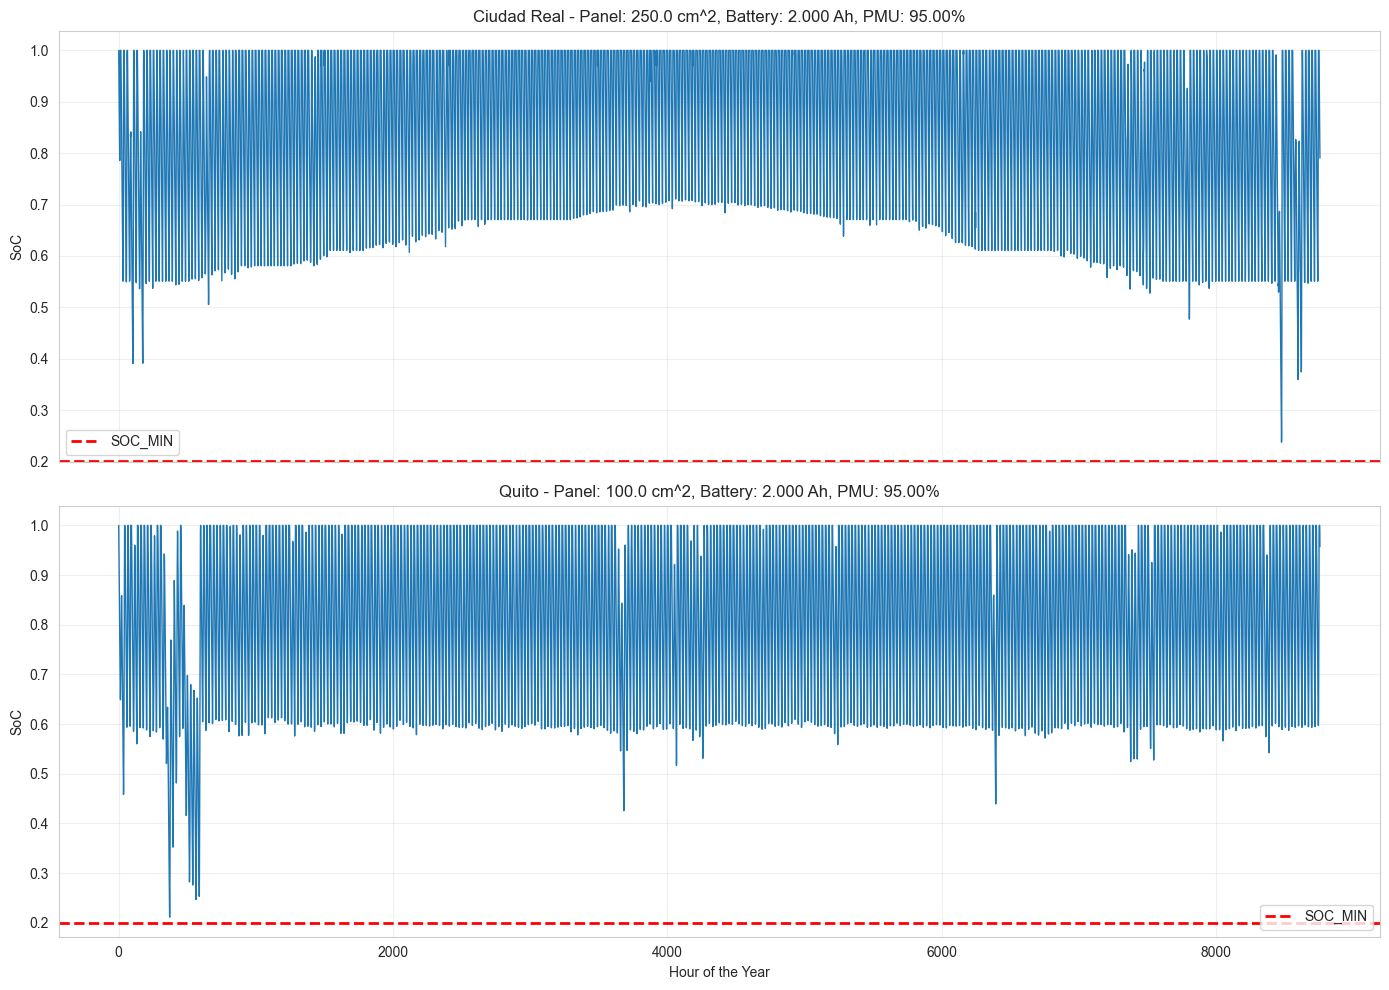

In [15]:
# Plot SoC evolution for the best configuration of each location
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for idx, (location, results) in enumerate(all_results.items()):
    summary = results['summary']
    df_soc = results['df_soc']

    # Get the best configuration
    viable = summary[summary['viable'] == True]
    if len(viable) > 0:
        best = viable.loc[viable['score'].idxmax()]

        # Filter SoC data for this configuration
        soc_data = df_soc[
            (df_soc['panel_area_m2'] == best['panel_area_m2']) &
            (df_soc['C_batt_Ah'] == best['C_batt_Ah']) &
            (df_soc['eta_PMU'] == best['eta_PMU'])
        ].copy()

        # Plot
        ax = axes[idx]
        ax.plot(soc_data['hour_index'], soc_data['SoC'], linewidth=1)
        ax.axhline(y=config.SOC_MIN, color='r', linestyle='--', linewidth=2, label='SOC_MIN')
        ax.set_ylabel('SoC')
        ax.set_title(f"{location} - Panel: {best['panel_area_m2']*10000:.1f} cm^2, "
                    f"Battery: {best['C_batt_Ah']:.3f} Ah, PMU: {best['eta_PMU']:.2%}")
        ax.legend()
        ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Hour of the Year')
plt.tight_layout()
plt.show()

## 8. Final Summary Table

In [16]:
# Create summary table with all relevant information
summary_table = df_best[['location', 'panel_area_m2', 'C_batt_Ah', 'eta_PMU',
                         'score', 'min_SoC', 'avg_SoC']].copy()

summary_table['Panel (cm^2)'] = (summary_table['panel_area_m2'] * 10000).round(2)
summary_table['Battery (Wh)'] = (summary_table['C_batt_Ah'] * config.BATTERY_VOLTAGE).round(2)
summary_table['PMU (%)'] = (summary_table['eta_PMU'] * 100).round(1)
summary_table['Score'] = summary_table['score'].round(4)
summary_table['SoC min (%)'] = (summary_table['min_SoC'] * 100).round(1)
summary_table['SoC avg (%)'] = (summary_table['avg_SoC'] * 100).round(1)

final_table = summary_table[['location', 'Panel (cm^2)', 'Battery (Wh)',
                             'PMU (%)', 'Score', 'SoC min (%)', 'SoC avg (%)']]
final_table = final_table.rename(columns={'location': 'Location'})

print("\n" + "=" * 100)
print("FINAL SUMMARY - BEST CONFIGURATIONS BY LOCATION")
print("=" * 100)
print(final_table.to_string(index=False))
print("=" * 100)


FINAL SUMMARY - BEST CONFIGURATIONS BY LOCATION
   Location  Panel (cm^2)  Battery (Wh)  PMU (%)  Score  SoC min (%)  SoC avg (%)
Ciudad Real         250.0          7.40     95.0 0.3128         23.8         85.7
Ciudad Real         250.0          7.40     98.0 0.3051         29.2         86.4
Ciudad Real         160.0         11.84     98.0 0.3000         28.4         88.5
Ciudad Real         250.0          8.51     95.0 0.2787         33.7         87.5
Ciudad Real         310.0          5.92     98.0 0.2787         23.2         83.9
Ciudad Real         250.0          8.51     98.0 0.2711         38.4         88.2
Ciudad Real         250.0          9.25     90.0 0.2694         26.2         87.3
Ciudad Real         250.0          9.25     95.0 0.2561         39.0         88.5
Ciudad Real         310.0          7.40     90.0 0.2508         24.9         85.3
Ciudad Real         250.0          9.25     98.0 0.2484         43.3         89.1
      Quito         100.0          7.40     95.0 